In [4]:
# Cài đặt thư viện nếu chưa có
!pip install opencv-python

import cv2 as cv
import numpy as np
import matplotlib.pyplot as TNKY # Đổi tên plt thành TNKY theo yêu cầu

# Đọc ảnh input (Đảm bảo bạn đã upload file hinh1.jpg vào Colab)
img = cv.imread('hinh1.jpg')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

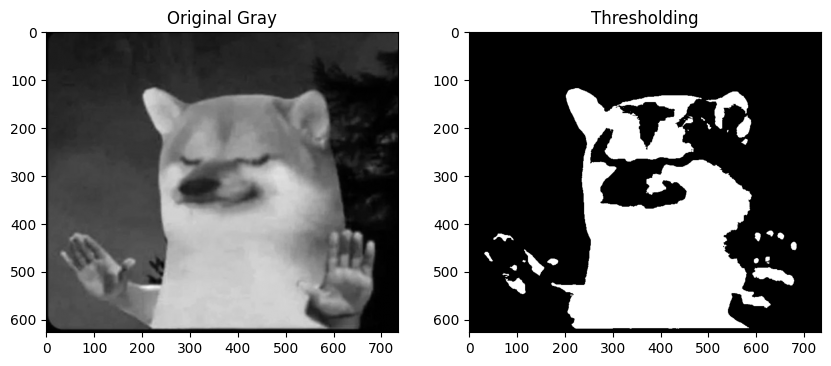

In [5]:
#1. Thresholding
# Phân ngưỡng nhị phân với ngưỡng cố định (ví dụ: 127)
ret, thresh1 = cv.threshold(img_gray, 127, 255, cv.THRESH_BINARY)

TNKY.figure(figsize=(10, 5))
TNKY.subplot(1, 2, 1), TNKY.imshow(img_gray, cmap='gray'), TNKY.title('Original Gray')
TNKY.subplot(1, 2, 2), TNKY.imshow(thresh1, cmap='gray'), TNKY.title('Thresholding')
TNKY.show()

Giá trị ngưỡng tối ưu tìm được bởi Otsu: 153.0


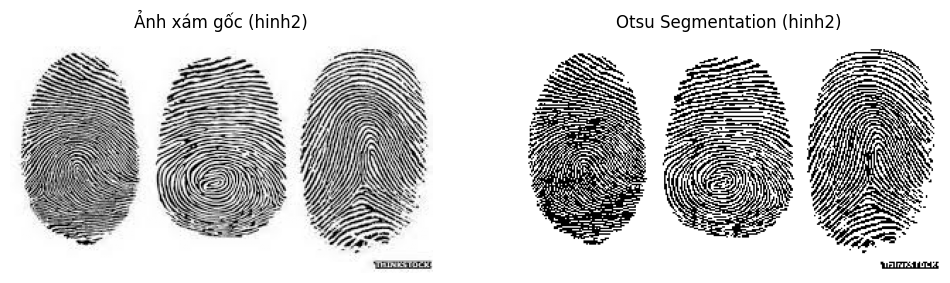

In [7]:
# 2.
# Otsu's thresholding
import cv2 as cv
import numpy as np
import matplotlib.pyplot as TNKY # Đổi tên theo yêu cầu mới của Lil

# Đọc ảnh thứ hai (Đảm bảo bạn đã upload file hinh2.jpg vào cùng folder)
img2 = cv.imread('hinh2.jpg')

# Kiểm tra nếu ảnh tồn tại trước khi xử lý
if img2 is None:
    print("Lỗi: Không tìm thấy file 'hinh2.jpg'. Lil hãy kiểm tra lại tên file nhé!")
else:
    img2_gray = cv.cvtColor(img2, cv.COLOR_BGR2GRAY)

    ret2, th2 = cv.threshold(img2_gray, 0, 255, cv.THRESH_BINARY + cv.THRESH_OTSU)

    # In ra giá trị ngưỡng mà Otsu đã tự động tìm được
    print(f"Giá trị ngưỡng tối ưu tìm được bởi Otsu: {ret2}")

    # Hiển thị kết quả bằng TNKY
    TNKY.figure(figsize=(12, 6))

    TNKY.subplot(1, 2, 1)
    TNKY.imshow(img2_gray, cmap='gray')
    TNKY.title('Ảnh xám gốc (hinh2)')
    TNKY.axis('off')

    TNKY.subplot(1, 2, 2)
    TNKY.imshow(th2, cmap='gray')
    TNKY.title('Otsu Segmentation (hinh2)')
    TNKY.axis('off')

    TNKY.show()

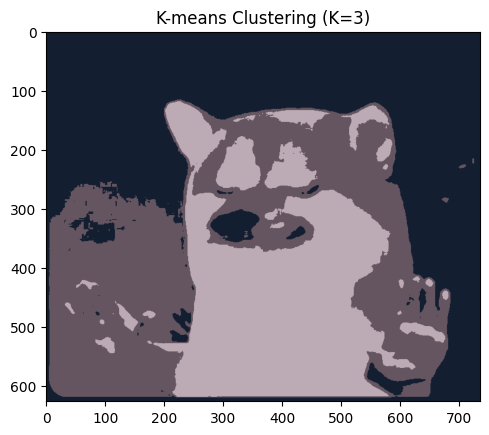

In [8]:
# 3. K-means Clustering
# Biến đổi ảnh thành mảng 2D cho K-means
pixel_values = img_rgb.reshape((-1, 3))
pixel_values = np.float32(pixel_values)

# Định nghĩa tiêu chí dừng
criteria = (cv.TERM_CRITERIA_EPS + cv.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 3 # Số lượng vùng muốn phân đoạn
_, labels, centers = cv.kmeans(pixel_values, K, None, criteria, 10, cv.KMEANS_RANDOM_CENTERS)

# Chuyển dữ liệu về lại dạng ảnh
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
segmented_image = segmented_data.reshape((img_rgb.shape))

TNKY.imshow(segmented_image)
TNKY.title('K-means Clustering (K=3)')
TNKY.show()


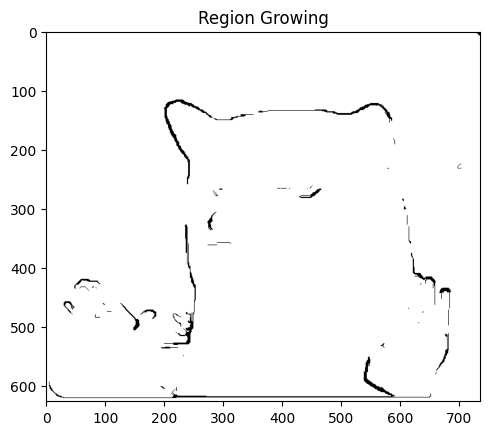

In [9]:
#4.Region Growing (Phát triển vùng)
def region_growing(img, seed):
    list_seeds = [seed]
    out_img = np.zeros_like(img)
    reg_threshold = 5
    while(len(list_seeds) > 0):
        pix = list_seeds.pop(0)
        out_img[pix[0], pix[1]] = 255
        for i in [-1, 0, 1]:
            for j in [-1, 0, 1]:
                if 0 <= pix[0] + i < img.shape[0] and 0 <= pix[1] + j < img.shape[1]:
                    if out_img[pix[0] + i, pix[1] + j] == 0 and abs(int(img[pix[0] + i, pix[1] + j]) - int(img[pix[0], pix[1]])) < reg_threshold:
                        out_img[pix[0] + i, pix[1] + j] = 255
                        list_seeds.append((pix[0] + i, pix[1] + j))
    return out_img

# Chọn điểm seed (ví dụ tâm ảnh)
seed_point = (img_gray.shape[0]//2, img_gray.shape[1]//2)
region_img = region_growing(img_gray, seed_point)
TNKY.imshow(region_img, cmap='gray')
TNKY.title('Region Growing')
TNKY.show()

Đang thực hiện phân đoạn Split and Merge... có thể mất vài giây...
Hoàn thành!


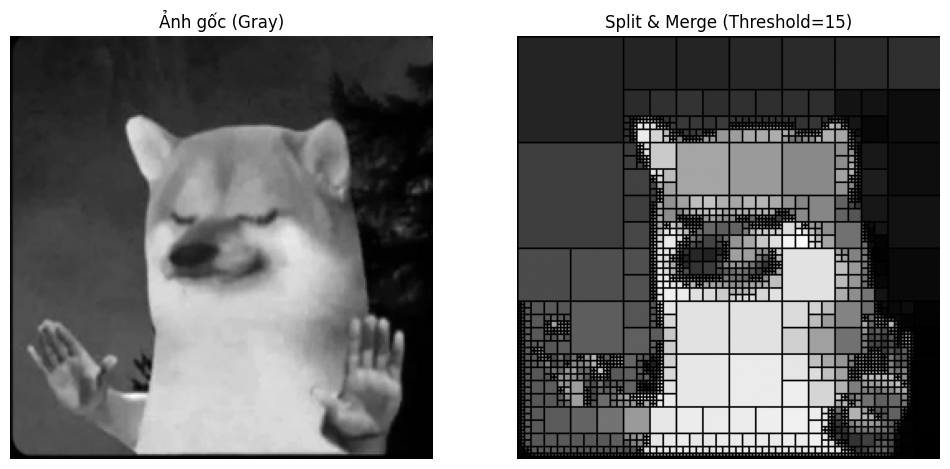

In [10]:
# 5.
import cv2 as cv
import numpy as np
import matplotlib.pyplot as Lil # Tuân thủ yêu cầu đặt tên của Lil

# 1. Đọc ảnh input (Đảm bảo đã upload file hinh1.jpg)
img = cv.imread('hinh1.jpg')
# Nên resize ảnh nhỏ lại để thuật toán chạy nhanh hơn trên Colab
img = cv.resize(img, (256, 256))
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)


# --- Định nghĩa các hàm bổ trợ cho Split and Merge ---

def is_homogeneous(image_part, standard_deviation_threshold=10):
    """Kiểm tra xem một vùng ảnh có đồng nhất không dựa trên độ lệch chuẩn."""
    # Nếu vùng quá nhỏ, coi như đồng nhất
    if image_part.shape[0] <= 2 or image_part.shape[1] <= 2:
        return True

    # Tính độ lệch chuẩn của các giá trị pixel trong vùng
    std_dev = np.std(image_part)
    return std_dev < standard_deviation_threshold

def split_image(image, x, y, w, h, out_img, threshold):
    """Hàm đệ quy để thực hiện bước Split."""
    vung_anh = image[y:y+h, x:x+w]

    if is_homogeneous(vung_anh, threshold):
        # Nếu đồng nhất, gán giá trị trung bình cho toàn vùng
        average_color = np.mean(vung_anh)
        out_img[y:y+h, x:x+w] = average_color
        # Vẽ đường viền để dễ hình dung cấu trúc Quadtree (tùy chọn)
        cv.rectangle(out_img, (x, y), (x+w, y+h), (0), 1)
    else:
        # Nếu không đồng nhất, chia làm 4
        half_w = w // 2
        half_h = h // 2

        # Đệ quy cho 4 vùng con: Top-Left, Top-Right, Bottom-Left, Bottom-Right
        split_image(image, x, y, half_w, half_h, out_img, threshold)
        split_image(image, x + half_w, y, half_w, half_h, out_img, threshold)
        split_image(image, x, y + half_h, half_w, half_h, out_img, threshold)
        split_image(image, x + half_w, y + half_h, half_w, half_h, out_img, threshold)

# --- Thực hiện thuật toán ---

# Khởi tạo ảnh kết quả
height, width = img_gray.shape
split_merge_img = np.zeros((height, width), np.uint8)

# Thiết lập ngưỡng đồng nhất (giá trị càng thấp, chia càng chi tiết)
threshold_val = 15

# Gọi hàm Split bắt đầu từ toàn bộ ảnh
print("Đang thực hiện phân đoạn Split and Merge... có thể mất vài giây...")
split_image(img_gray, 0, 0, width, height, split_merge_img, threshold_val)
print("Hoàn thành!")

# --- Hiển thị kết quả ---
Lil.figure(figsize=(12, 6))

Lil.subplot(1, 2, 1)
Lil.imshow(img_gray, cmap='gray')
Lil.title('Ảnh gốc (Gray)')
Lil.axis('off')

Lil.subplot(1, 2, 2)
Lil.imshow(split_merge_img, cmap='gray')
Lil.title(f'Split & Merge (Threshold={threshold_val})')
Lil.axis('off')

Lil.show()

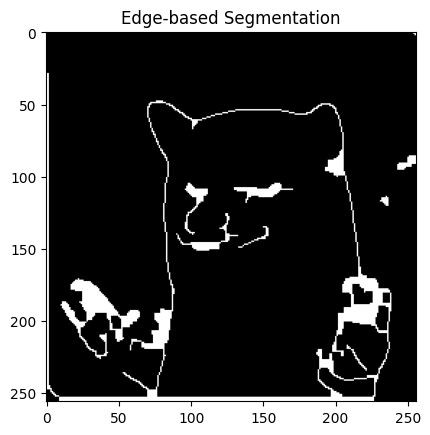

In [11]:
# 6.
# Sử dụng Canny để tìm cạnh
edges = cv.Canny(img_gray, 100, 200)

# Dùng morphology để đóng các lỗ hổng trên cạnh
kernel = np.ones((5,5), np.uint8)
closing = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel)

Lil.imshow(closing, cmap='gray')
Lil.title('Edge-based Segmentation')
Lil.show()